<a href="https://www.kaggle.com/code/aamir28/mount-vesuvius-seismic-activity?scriptVersionId=329355561" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#0d0907;border-radius:16px;font-family:'Segoe UI',monospace;overflow:hidden;border:1px solid #3d2418;">

  <div style="background:linear-gradient(90deg,#3d0c0c,#7c2d12,#9a3412);padding:16px 36px;display:flex;align-items:center;justify-content:space-between;">
    <div style="display:flex;align-items:center;gap:14px;">
      <span style="font-size:2rem;">🌋</span>
      <div>
        <div style="font-size:1.1rem;font-weight:900;color:#fed7aa;letter-spacing:1px;">MOUNT VESUVIUS SEISMIC MONITORING NETWORK</div>
        <div style="font-size:0.65rem;color:#fb923c;letter-spacing:3px;margin-top:2px;">EVENT CATALOG 2011–2024 · OSSERVATORIO VESUVIANO STYLE ANALYSIS</div>
      </div>
    </div>
    <div style="text-align:right;font-size:0.65rem;color:#9a3412;letter-spacing:2px;">KAGGLE NOTEBOOK<br>MUHAMMAD AAMIR</div>
  </div>

  <!-- Station readout bar -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#170d08;border-bottom:1px solid #3d2418;">
    <div style="padding:14px 16px;border-right:1px solid #3d2418;">
      <div style="font-size:0.58rem;color:#fb923c;letter-spacing:2px;margin-bottom:5px;">EVENT LOG</div>
      <div style="font-size:1.4rem;font-weight:800;color:#fed7aa;">36,000+</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #3d2418;">
      <div style="font-size:0.58rem;color:#fb923c;letter-spacing:2px;margin-bottom:5px;">MONITORING SPAN</div>
      <div style="font-size:1.4rem;font-weight:800;color:#fed7aa;">2011–2024</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #3d2418;">
      <div style="font-size:0.58rem;color:#fb923c;letter-spacing:2px;margin-bottom:5px;">SPATIAL COVERAGE</div>
      <div style="font-size:1.4rem;font-weight:800;color:#facc15;">~75% complete</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #3d2418;">
      <div style="font-size:0.58rem;color:#fb923c;letter-spacing:2px;margin-bottom:5px;">DEPTH RECORDS</div>
      <div style="font-size:1.4rem;font-weight:800;color:#facc15;">~70% complete</div>
    </div>
    <div style="padding:14px 16px;">
      <div style="font-size:0.58rem;color:#fb923c;letter-spacing:2px;margin-bottom:5px;">REVIEW STATUS</div>
      <div style="font-size:1.4rem;font-weight:800;color:#86efac;">Revised / Prelim</div>
    </div>
  </div>

  <div style="padding:22px 36px;display:grid;grid-template-columns:1fr 1fr;gap:20px;">
    <div>
      <div style="font-size:0.62rem;letter-spacing:3px;color:#fb923c;margin-bottom:10px;">▌ DATASET BRIEF</div>
      <p style="color:#a8826f;font-size:0.82rem;line-height:1.8;margin:0;">13+ years of seismic monitoring at Mount Vesuvius — one of the most studied and closely-watched volcanic systems on Earth. Every row is a detected earthquake: timestamp, location, depth, duration magnitude (Md), and a quality flag (<em>revised</em> vs <em>preliminary</em>). Spatial fields carry meaningful missingness, concentrated in early years and preliminary-review events — itself a signal about monitoring infrastructure evolution over time.</p>
    </div>
    <div>
      <div style="font-size:0.62rem;letter-spacing:3px;color:#fb923c;margin-bottom:10px;">▌ ANALYSIS OBJECTIVES</div>
      <div style="display:flex;flex-direction:column;gap:7px;">
        <div style="background:#170d08;border-left:3px solid #fb923c;padding:7px 12px;font-size:0.78rem;color:#c9a892;">Map seismic activity over time — are swarms detectable?</div>
        <div style="background:#170d08;border-left:3px solid #facc15;padding:7px 12px;font-size:0.78rem;color:#c9a892;">Geospatial clustering of event epicentres</div>
        <div style="background:#170d08;border-left:3px solid #86efac;padding:7px 12px;font-size:0.78rem;color:#c9a892;">Predict magnitude from depth, location, timing</div>
        <div style="background:#170d08;border-left:3px solid #f87171;padding:7px 12px;font-size:0.78rem;color:#c9a892;">Quantify data quality: revised vs preliminary gaps</div>
      </div>
    </div>
  </div>

  <div style="background:#170d08;padding:10px 36px;border-top:1px solid #3d2418;">
    <p style="margin:0;font-size:0.72rem;color:#7c5a45;line-height:1.6;">
      ⚠ <strong style='color:#fb923c;'>Known data quality flags (per provider notes):</strong> negative depth_km and negative
      duration_magnitude_md values exist and likely represent measurement artefacts rather than physical events;
      md_error is near-constant (~0.3) across most rows; area/type columns are constant and are dropped early.
    </p>
  </div>
</div>


## 🌋 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Data Quality Audit](#2)
3. [Cleaning & Anomaly Handling](#3)
4. [Temporal Feature Engineering](#4)
5. [Magnitude Distribution & Trends](#5)
6. [Depth Analysis](#6)
7. [Geospatial Analysis & Clustering](#7)
8. [Revised vs Preliminary — Data Quality Over Time](#8)
9. [Seismic Swarm Detection](#9)
10. [Correlation Heatmap](#10)
11. [ML Regression — Predicting Magnitude](#11)
12. [ML Classification — Predicting Review Level](#12)
13. [Key Takeaways](#13)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# ── Magma / seismograph dark theme ──────────────────────────────────────────
BG, PANEL, GRID = '#0d0907','#170d08','#3d2418'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#c9a892','axes.titlecolor':'#fed7aa','axes.titlesize':13,
    'xtick.color':'#7c5a45','ytick.color':'#7c5a45','text.color':'#c9a892',
    'grid.color':'#241409','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

LAVA   = '#ef4444'
EMBER  = '#fb923c'
GOLD   = '#facc15'
SAFE   = '#86efac'
SMOKE  = '#94a3b8'
PURPLE = '#a78bfa'
REVIEW_PAL = {'revised': SAFE, 'preliminary': EMBER}
CMAP_LAVA = LinearSegmentedColormap.from_list('lv', [BG, EMBER, LAVA])
CMAP_DEPTH= LinearSegmentedColormap.from_list('dp', [GOLD, BG, PURPLE])
print('✅  Magma seismograph theme active.')


✅  Magma seismograph theme active.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ibrahimqasimi/mount-vesuvius-seismic-activity-2011-2024/25_Mount_Vesuvius_Seismic.csv',
                 parse_dates=['time'])
print(f'Shape: {df.shape}')
print(f'Date range: {df["time"].min()}  →  {df["time"].max()}')
df.head(8)

Shape: (12027, 11)
Date range: 2011-04-20 00:27:24+00:00  →  2024-12-31 17:02:32+00:00


,event_id,time,latitude,longitude,depth_km,duration_magnitude_md,md_error,area,type,review_level,year
0,4251,2011-04-20 00:27:24+00:00,40.818000,14.430000,0.42,1.2,0.3,Mount Vesuvius,earthquake,revised,2011
1,4252,2012-06-19 21:29:48+00:00,40.808833,14.427167,1.31,0.7,0.3,Mount Vesuvius,earthquake,revised,2012
2,22547,2013-01-01 07:34:46+00:00,40.822170,14.428000,0.06,2.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
3,22546,2013-01-03 16:06:48+00:00,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
4,22545,2013-01-03 16:07:37+00:00,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
5,22544,2013-01-04 06:42:50+00:00,NaN,NaN,NaN,0.0,0.3,Mount Vesuvius,earthquake,preliminary,2013
6,22543,2013-01-04 18:37:31+00:00,NaN,NaN,NaN,0.8,0.3,Mount Vesuvius,earthquake,preliminary,2013
7,22542,2013-01-05 01:55:31+00:00,NaN,NaN,NaN,1.4,0.3,Mount Vesuvius,earthquake,preliminary,2013


## 2. EDA & Data Quality Audit <a id='2'></a>


In [3]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Value Audit ===')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_table = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
print(miss_table[miss_table['missing_count']>0])

print('\n=== Constant Columns Check ===')
for col in ['area','type']:
    if col in df.columns:
        print(f'  {col}: unique values = {df[col].unique().tolist()}')

print('\n=== Descriptive Statistics ===')
df.describe().round(3)


=== Data Types ===
event_id                               int64
time                     datetime64[ns, UTC]
latitude                             float64
longitude                            float64
depth_km                             float64
duration_magnitude_md                float64
md_error                             float64
area                                  object
type                                  object
review_level                          object
year                                   int64
dtype: object

=== Missing Value Audit ===
                       missing_count  missing_pct
latitude                        3433        28.54
longitude                       3433        28.54
depth_km                        3433        28.54
duration_magnitude_md            399         3.32
md_error                         399         3.32

=== Constant Columns Check ===
  area: unique values = ['Mount Vesuvius']
  type: unique values = ['earthquake']

=== Descriptive Statistics =

,event_id,latitude,longitude,depth_km,duration_magnitude_md,md_error,year
count,12027.000,8594.000,8594.000,8594.000,11628.000,11628.0,12027.000
mean,15494.116,40.821,14.427,0.407,0.177,0.3,2018.878
std,11014.195,0.003,0.005,0.498,0.556,0.0,3.280
min,102.000,40.799,14.349,0.010,-2.000,0.3,2011.000
25%,5965.500,40.819,14.425,0.140,-0.200,0.3,2016.000
50%,14981.000,40.821,14.427,0.240,0.100,0.3,2019.000
75%,21387.500,40.823,14.430,0.428,0.500,0.3,2022.000
max,40802.000,40.860,14.475,9.350,3.100,0.3,2024.000


In [4]:
# Anomaly scan: negative values flagged in provider notes
neg_depth = (df['depth_km'] < 0).sum()
neg_mag   = (df['duration_magnitude_md'] < 0).sum()
zero_depth = (df['depth_km'] == 0).sum()
print(f'Negative depth_km records: {neg_depth} ({neg_depth/len(df)*100:.2f}%)')
print(f'Negative duration_magnitude_md records: {neg_mag} ({neg_mag/len(df)*100:.2f}%)')
print(f'Zero depth_km records: {zero_depth} ({zero_depth/len(df)*100:.2f}%)')
print(f'\nmd_error unique values: {sorted(df["md_error"].dropna().unique())[:10]}')
print(f'md_error mode: {df["md_error"].mode().values}')
print(f'\nreview_level distribution:')
print(df['review_level'].value_counts())
print(f'\nFully-missing spatial rows (lat AND lon both NA): '
      f'{df[df["latitude"].isna() & df["longitude"].isna()].shape[0]}')


Negative depth_km records: 0 (0.00%)
Negative duration_magnitude_md records: 4279 (35.58%)
Zero depth_km records: 0 (0.00%)

md_error unique values: [np.float64(0.3)]
md_error mode: [0.3]

review_level distribution:
review_level
preliminary    12025
revised            2
Name: count, dtype: int64

Fully-missing spatial rows (lat AND lon both NA): 3433


## 3. Cleaning & Anomaly Handling <a id='3'></a>


In [5]:
# Drop constant / redundant columns flagged in dataset notes
df_clean = df.drop(columns=[c for c in ['area','type','year'] if c in df.columns]).copy()

# Flag (not silently drop) anomalous values — keep for transparency, mark for exclusion in modelling
df_clean['depth_anomaly'] = df_clean['depth_km'] < 0
df_clean['magnitude_anomaly'] = df_clean['duration_magnitude_md'] < 0
df_clean['spatial_missing'] = df_clean['latitude'].isna() | df_clean['longitude'].isna()

# Re-extract year/month/etc directly from time rather than trusting the dropped year column
df_clean['year']  = df_clean['time'].dt.year

# Clean depth: treat negative depth as missing (physically implausible for sub-surface events)
df_clean['depth_km_clean'] = df_clean['depth_km'].where(df_clean['depth_km'] >= 0)

# Clean magnitude: keep but flag (small negative Md can sometimes be valid for micro-events,
# so we do NOT discard automatically — analyst judgement call documented here)
df_clean['md_clean'] = df_clean['duration_magnitude_md']

print(f'Rows total: {len(df_clean):,}')
print(f'Rows with spatial data: {(~df_clean["spatial_missing"]).sum():,} '
      f'({(~df_clean["spatial_missing"]).mean()*100:.1f}%)')
print(f'Rows flagged depth anomaly: {df_clean["depth_anomaly"].sum():,}')
print(f'Rows flagged magnitude anomaly: {df_clean["magnitude_anomaly"].sum():,}')
df_clean.head(5)


Rows total: 12,027
Rows with spatial data: 8,594 (71.5%)
Rows flagged depth anomaly: 0
Rows flagged magnitude anomaly: 4,279


,event_id,time,latitude,longitude,depth_km,duration_magnitude_md,md_error,review_level,depth_anomaly,magnitude_anomaly,spatial_missing,year,depth_km_clean,md_clean
0,4251,2011-04-20 00:27:24+00:00,40.818000,14.430000,0.42,1.2,0.3,revised,False,False,False,2011,0.42,1.2
1,4252,2012-06-19 21:29:48+00:00,40.808833,14.427167,1.31,0.7,0.3,revised,False,False,False,2012,1.31,0.7
2,22547,2013-01-01 07:34:46+00:00,40.822170,14.428000,0.06,2.2,0.3,preliminary,False,False,False,2013,0.06,2.2
3,22546,2013-01-03 16:06:48+00:00,NaN,NaN,NaN,0.2,0.3,preliminary,False,False,True,2013,NaN,0.2
4,22545,2013-01-03 16:07:37+00:00,NaN,NaN,NaN,0.2,0.3,preliminary,False,False,True,2013,NaN,0.2


## 4. Temporal Feature Engineering <a id='4'></a>


In [6]:
df_clean['hour']       = df_clean['time'].dt.hour
df_clean['day']        = df_clean['time'].dt.day
df_clean['month']      = df_clean['time'].dt.month
df_clean['dow']        = df_clean['time'].dt.dayofweek   # 0=Mon
df_clean['season']     = df_clean['month'].map({12:'Winter',1:'Winter',2:'Winter',
                                                  3:'Spring',4:'Spring',5:'Spring',
                                                  6:'Summer',7:'Summer',8:'Summer',
                                                  9:'Autumn',10:'Autumn',11:'Autumn'})

# Inter-arrival time between consecutive events (sorted by time) — key swarm-detection feature
df_sorted = df_clean.sort_values('time').reset_index(drop=True)
df_sorted['inter_arrival_hours'] = df_sorted['time'].diff().dt.total_seconds() / 3600

# Daily and monthly event density
daily_counts = df_clean.set_index('time').resample('D').size()
monthly_counts = df_clean.set_index('time').resample('M').size()

print('Temporal features created: hour, day, month, dow, season, inter_arrival_hours')
print(f'\nMedian inter-arrival time: {df_sorted["inter_arrival_hours"].median():.2f} hours')
print(f'Min inter-arrival time: {df_sorted["inter_arrival_hours"].min():.4f} hours '
      f'(closest pair of events — potential swarm signature)')
print(f'\nBusiest single day: {daily_counts.idxmax().date()} with {daily_counts.max()} events')
print(f'Busiest single month: {monthly_counts.idxmax().strftime("%Y-%m")} with {monthly_counts.max()} events')


Temporal features created: hour, day, month, dow, season, inter_arrival_hours

Median inter-arrival time: 2.63 hours
Min inter-arrival time: 0.0000 hours (closest pair of events — potential swarm signature)

Busiest single day: 2019-03-25 with 148 events
Busiest single month: 2019-03 with 247 events


## 5. Magnitude Distribution & Trends <a id='5'></a>


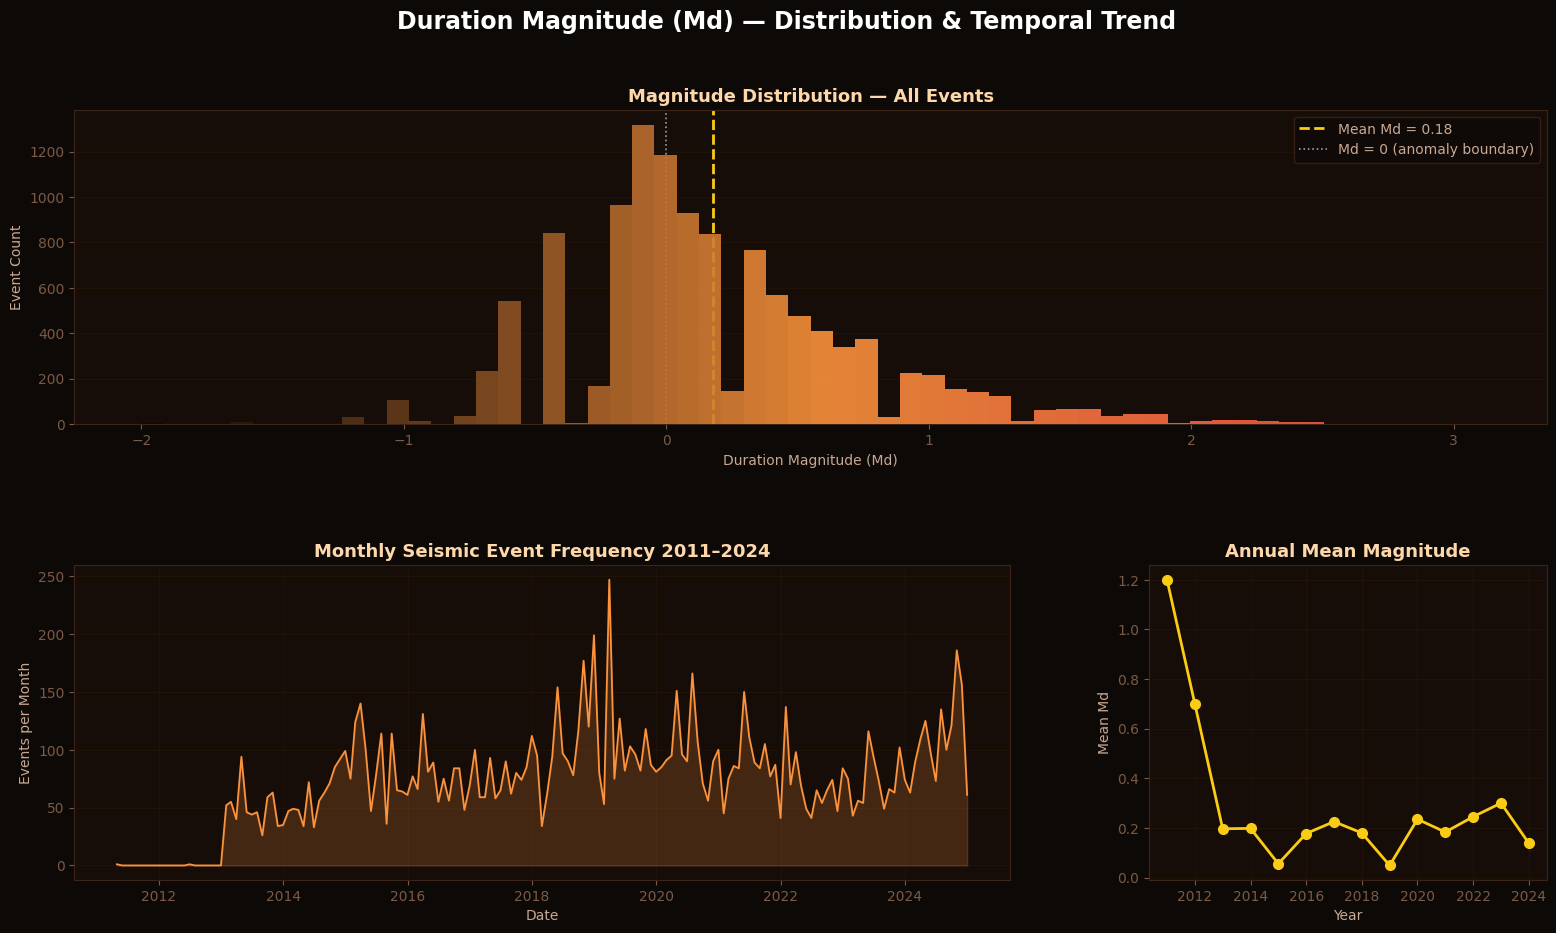

In [7]:
fig = plt.figure(figsize=(19, 10), facecolor=BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Duration Magnitude (Md) — Distribution & Temporal Trend', fontsize=17,
             fontweight='bold', color='white')

# 1. Histogram full width
ax = fig.add_subplot(gs[0, :])
ax.set_facecolor(PANEL)
mag_valid = df_clean['md_clean'].dropna()
n, bins, patches = ax.hist(mag_valid, bins=60, edgecolor='none', alpha=0.88, zorder=3)
for patch, left in zip(patches, bins[:-1]):
    t = (left - bins[0]) / (bins[-1] - bins[0] + 1e-9)
    patch.set_facecolor(CMAP_LAVA(t)); patch.set_alpha(0.9)
ax.axvline(mag_valid.mean(),   color=GOLD, lw=2, ls='--', label=f'Mean Md = {mag_valid.mean():.2f}')
ax.axvline(0, color=SMOKE, lw=1.2, ls=':', label='Md = 0 (anomaly boundary)')
ax.set_xlabel('Duration Magnitude (Md)'); ax.set_ylabel('Event Count')
ax.set_title('Magnitude Distribution — All Events', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Monthly event count time series
ax2 = fig.add_subplot(gs[1, :2])
ax2.set_facecolor(PANEL)
ax2.plot(monthly_counts.index, monthly_counts.values, color=EMBER, lw=1.3, zorder=3)
ax2.fill_between(monthly_counts.index, monthly_counts.values, alpha=0.2, color=EMBER)
ax2.set_xlabel('Date'); ax2.set_ylabel('Events per Month')
ax2.set_title('Monthly Seismic Event Frequency 2011–2024', fontweight='bold')
ax2.grid(True, zorder=0); ax2.set_axisbelow(True)

# 3. Annual mean magnitude trend
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor(PANEL)
annual_mag = df_clean.groupby('year')['md_clean'].mean()
ax3.plot(annual_mag.index, annual_mag.values, 'o-', color=GOLD, lw=2, ms=7, zorder=5)
ax3.set_xlabel('Year'); ax3.set_ylabel('Mean Md')
ax3.set_title('Annual Mean Magnitude', fontweight='bold')
ax3.grid(True, zorder=0); ax3.set_axisbelow(True)

plt.savefig('01_magnitude.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Depth Analysis <a id='6'></a>


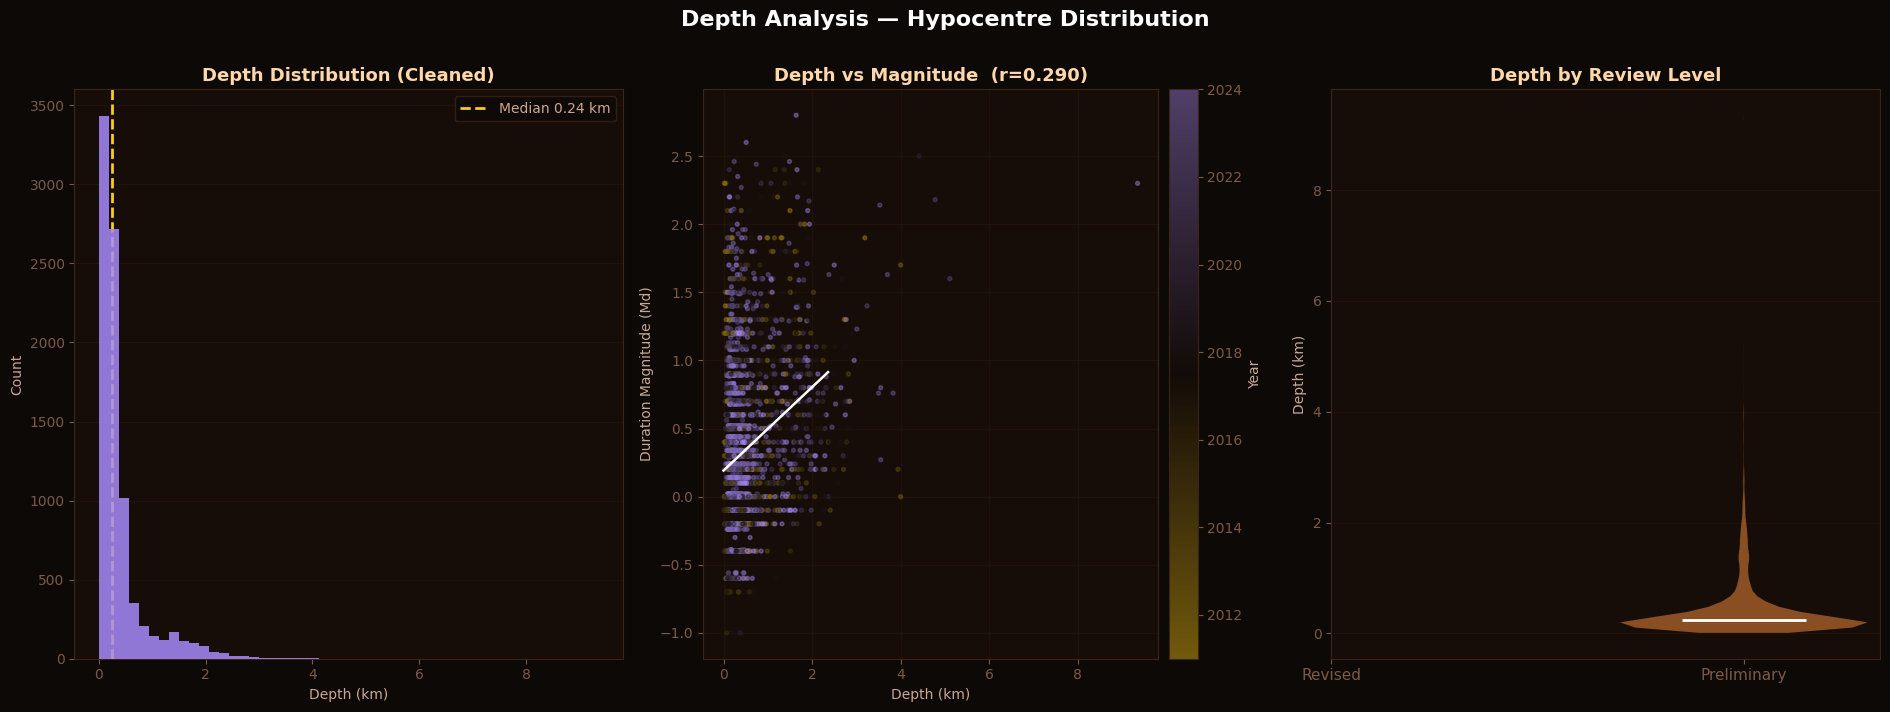

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Depth Analysis — Hypocentre Distribution', fontsize=16,
             fontweight='bold', color='white', y=1.01)

# 1. Depth histogram (cleaned, non-negative only)
ax = axes[0]
depth_valid = df_clean['depth_km_clean'].dropna()
ax.hist(depth_valid, bins=50, color=PURPLE, alpha=0.85, edgecolor='none', zorder=3)
ax.axvline(depth_valid.median(), color=GOLD, lw=2, ls='--',
           label=f'Median {depth_valid.median():.2f} km')
ax.set_xlabel('Depth (km)'); ax.set_ylabel('Count')
ax.set_title('Depth Distribution (Cleaned)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Depth vs Magnitude scatter
ax2 = axes[1]
valid = df_clean.dropna(subset=['depth_km_clean','md_clean'])
sample = valid.sample(min(5000, len(valid)), random_state=42)
sc = ax2.scatter(sample['depth_km_clean'], sample['md_clean'],
                 c=sample['year'], cmap=CMAP_DEPTH, s=8, alpha=0.4, zorder=3)
plt.colorbar(sc, ax=ax2, label='Year', pad=0.02)
m, b, r, p, _ = stats.linregress(valid['depth_km_clean'], valid['md_clean'])
xr = np.linspace(0, valid['depth_km_clean'].quantile(0.99), 80)
ax2.plot(xr, m*xr+b, color='white', lw=1.8, zorder=5)
ax2.set_xlabel('Depth (km)'); ax2.set_ylabel('Duration Magnitude (Md)')
ax2.set_title(f'Depth vs Magnitude  (r={r:.3f})', fontweight='bold')
ax2.grid(True, zorder=0); ax2.set_axisbelow(True)

# 3. Depth by review level (violin)
ax3 = axes[2]
for i, (lvl, color) in enumerate(REVIEW_PAL.items()):
    data = df_clean[df_clean['review_level']==lvl]['depth_km_clean'].dropna()
    if len(data) > 5:
        vp = ax3.violinplot(data, positions=[i], widths=0.6, showmedians=True, showextrema=False)
        for pc in vp['bodies']: pc.set_facecolor(color); pc.set_alpha(0.5)
        vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax3.set_xticks([0,1]); ax3.set_xticklabels(['Revised','Preliminary'], fontsize=11)
ax3.set_ylabel('Depth (km)')
ax3.set_title('Depth by Review Level', fontweight='bold')
ax3.grid(axis='y', zorder=0); ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_depth.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Geospatial Analysis & Clustering <a id='7'></a>


Events with valid coordinates: 8,594 of 12,027 (71.5%)


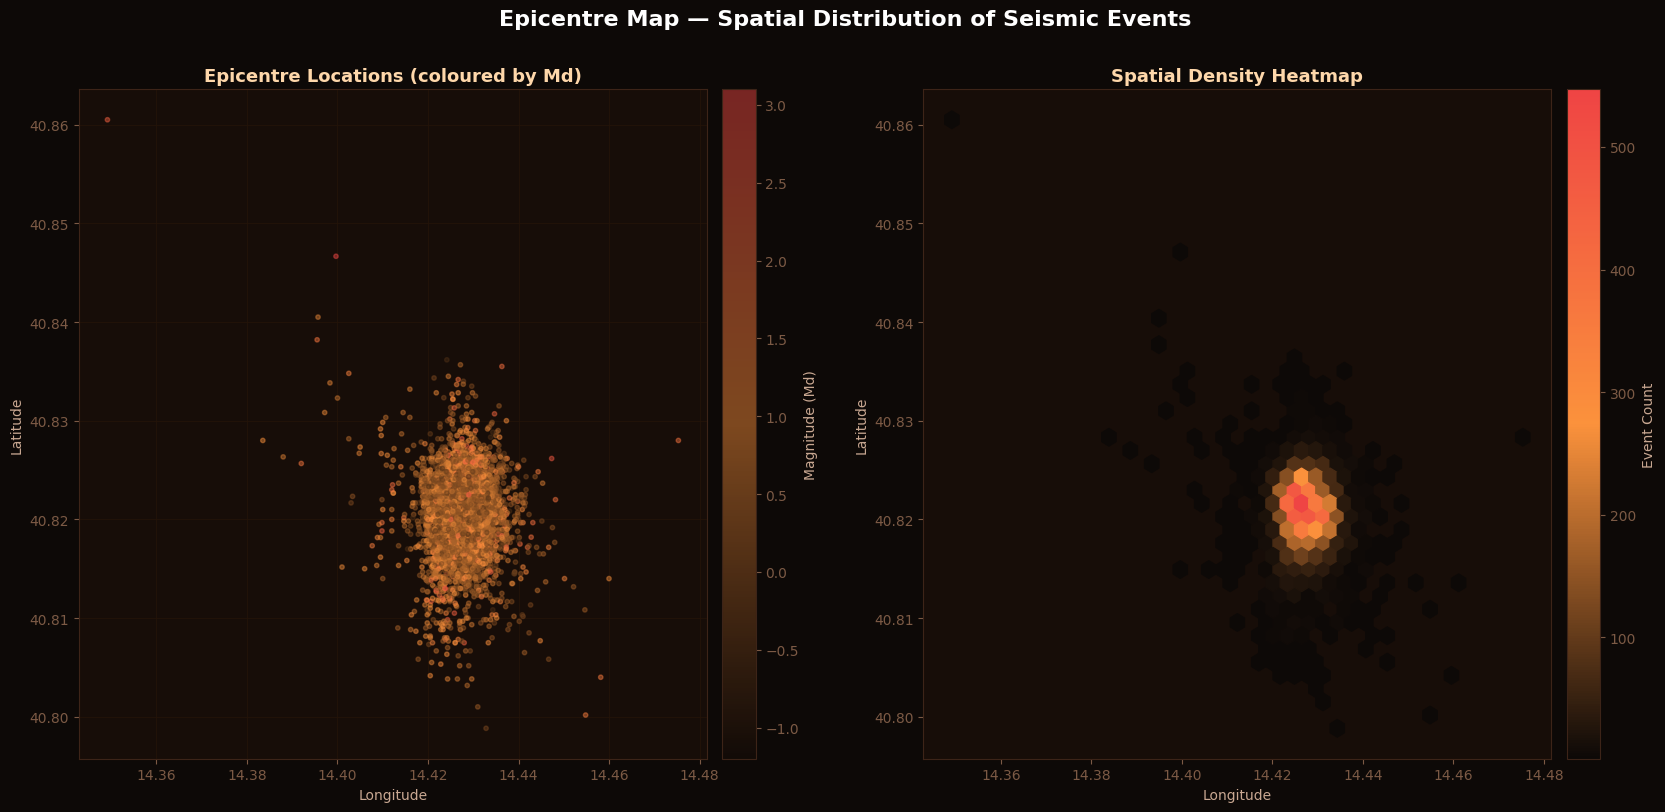

In [9]:
df_geo = df_clean.dropna(subset=['latitude','longitude']).copy()
print(f'Events with valid coordinates: {len(df_geo):,} of {len(df_clean):,} '
      f'({len(df_geo)/len(df_clean)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Epicentre Map — Spatial Distribution of Seismic Events', fontsize=16,
             fontweight='bold', color='white', y=1.01)

# 1. Scatter coloured by magnitude
ax = axes[0]
sc = ax.scatter(df_geo['longitude'], df_geo['latitude'],
                c=df_geo['md_clean'], cmap=CMAP_LAVA,
                s=10, alpha=0.45, zorder=3)
plt.colorbar(sc, ax=ax, label='Magnitude (Md)', pad=0.02)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Epicentre Locations (coloured by Md)', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. 2D density heatmap (hexbin)
ax2 = axes[1]
hb = ax2.hexbin(df_geo['longitude'], df_geo['latitude'], gridsize=40,
                cmap=CMAP_LAVA, mincnt=1)
plt.colorbar(hb, ax=ax2, label='Event Count', pad=0.02)
ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')
ax2.set_title('Spatial Density Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('03_geo_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


Silhouette scores by k:
  k=2: silhouette=0.3196
  k=3: silhouette=0.3455
  k=4: silhouette=0.3166
  k=5: silhouette=0.3062
  k=6: silhouette=0.3001
  k=7: silhouette=0.3011

Best k = 3 (silhouette = 0.3455)
Davies-Bouldin Index: 0.9357  (lower is better)


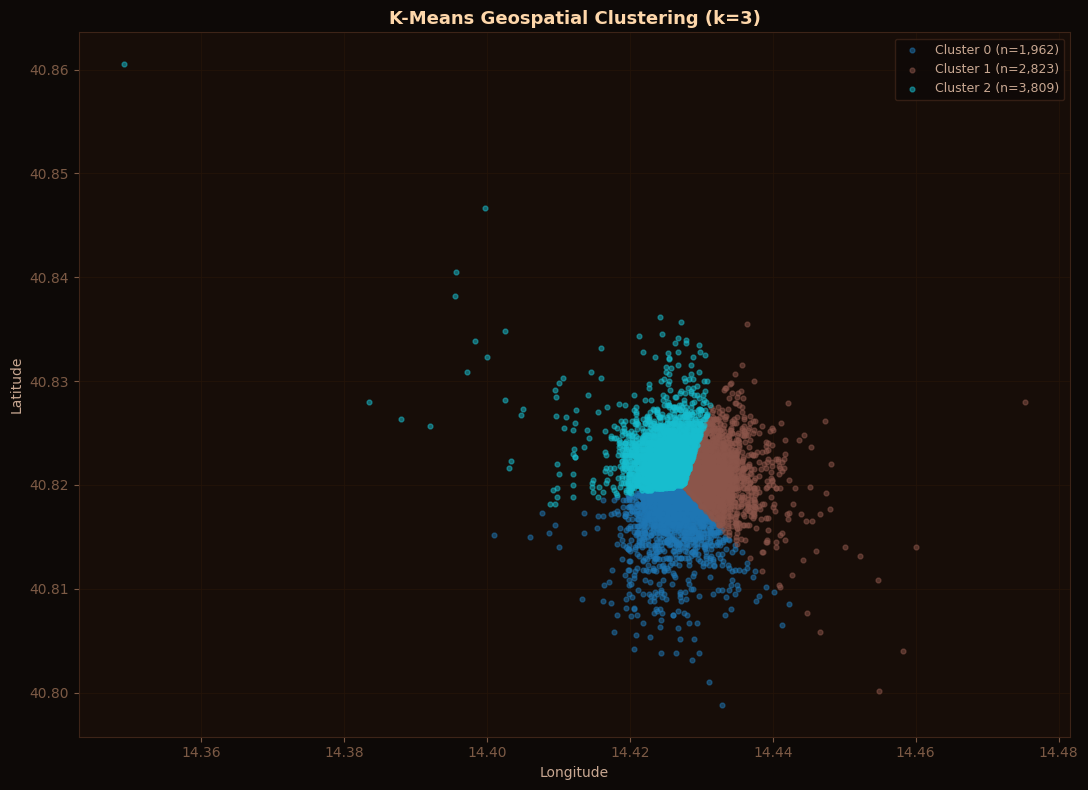

In [10]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

coords = df_geo[['latitude','longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)

# K-Means with elbow-informed k (try a small range, pick best silhouette)
best_k, best_score = 3, -1
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(coords_scaled)
    score = silhouette_score(coords_scaled, km.labels_)
    sil_scores[k] = score
    if score > best_score:
        best_k, best_score = k, score

print('Silhouette scores by k:')
for k, s in sil_scores.items():
    print(f'  k={k}: silhouette={s:.4f}')
print(f'\nBest k = {best_k} (silhouette = {best_score:.4f})')

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(coords_scaled)
df_geo['cluster'] = kmeans_final.labels_
db_score = davies_bouldin_score(coords_scaled, kmeans_final.labels_)
print(f'Davies-Bouldin Index: {db_score:.4f}  (lower is better)')

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k))
for c in range(best_k):
    sub = df_geo[df_geo['cluster']==c]
    ax.scatter(sub['longitude'], sub['latitude'], color=cluster_colors[c],
               s=12, alpha=0.5, label=f'Cluster {c} (n={len(sub):,})', zorder=3)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'K-Means Geospatial Clustering (k={best_k})', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('04_clustering.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Revised vs Preliminary — Data Quality Over Time <a id='8'></a>


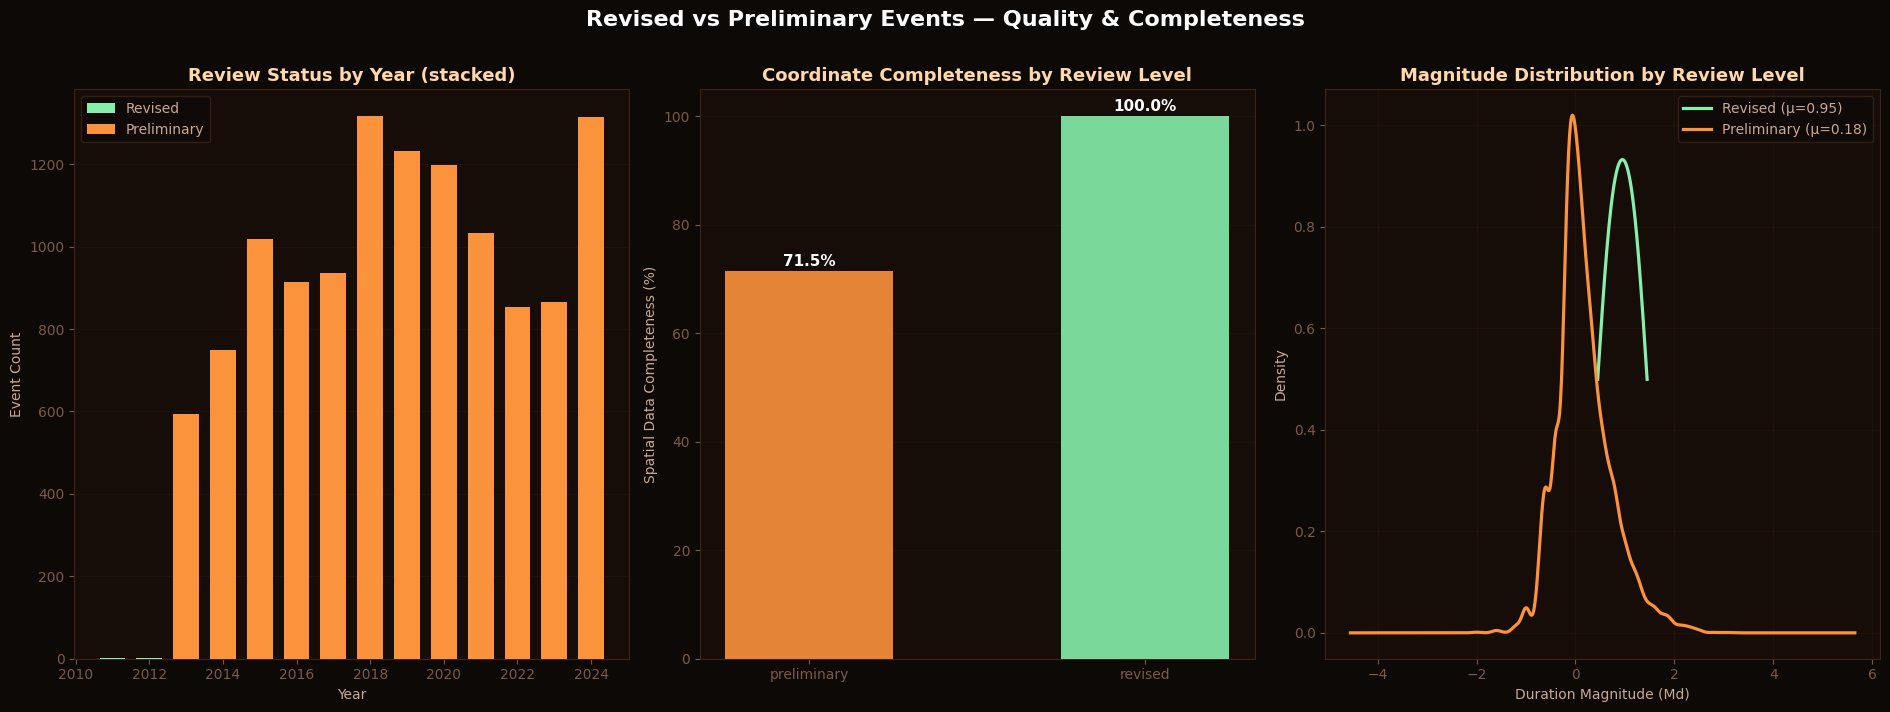

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Revised vs Preliminary Events — Quality & Completeness',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Review level counts by year (stacked)
ax = axes[0]
yr_review = df_clean.groupby(['year','review_level']).size().unstack(fill_value=0)
yr_review = yr_review.reindex(columns=['revised','preliminary'], fill_value=0)
years = yr_review.index
ax.bar(years, yr_review['revised'], color=SAFE, label='Revised', width=0.7, zorder=3)
ax.bar(years, yr_review['preliminary'], color=EMBER, label='Preliminary', width=0.7,
       bottom=yr_review['revised'], zorder=3)
ax.set_xlabel('Year'); ax.set_ylabel('Event Count')
ax.set_title('Review Status by Year (stacked)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Spatial completeness by review level
ax2 = axes[1]
completeness = (df_clean.groupby('review_level')['spatial_missing']
                 .apply(lambda x: (~x).mean()*100))
bars = ax2.bar(completeness.index, completeness.values,
               color=[REVIEW_PAL[l] for l in completeness.index],
               width=0.5, zorder=3, edgecolor='none', alpha=0.9)
ax2.set_ylabel('Spatial Data Completeness (%)')
ax2.set_title('Coordinate Completeness by Review Level', fontweight='bold')
ax2.set_ylim(0, 105)
for bar, v in zip(bars, completeness.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold', color='white')
ax2.grid(axis='y', zorder=0); ax2.set_axisbelow(True)

# 3. Magnitude KDE by review level
ax3 = axes[2]
for lvl, color in REVIEW_PAL.items():
    sub = df_clean[df_clean['review_level']==lvl]['md_clean'].dropna()
    sub.plot.kde(ax=ax3, color=color, lw=2.3, label=f'{lvl.title()} (μ={sub.mean():.2f})')
ax3.set_xlabel('Duration Magnitude (Md)'); ax3.set_ylabel('Density')
ax3.set_title('Magnitude Distribution by Review Level', fontweight='bold')
ax3.legend(fontsize=10); ax3.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('05_review_quality.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Seismic Swarm Detection <a id='9'></a>


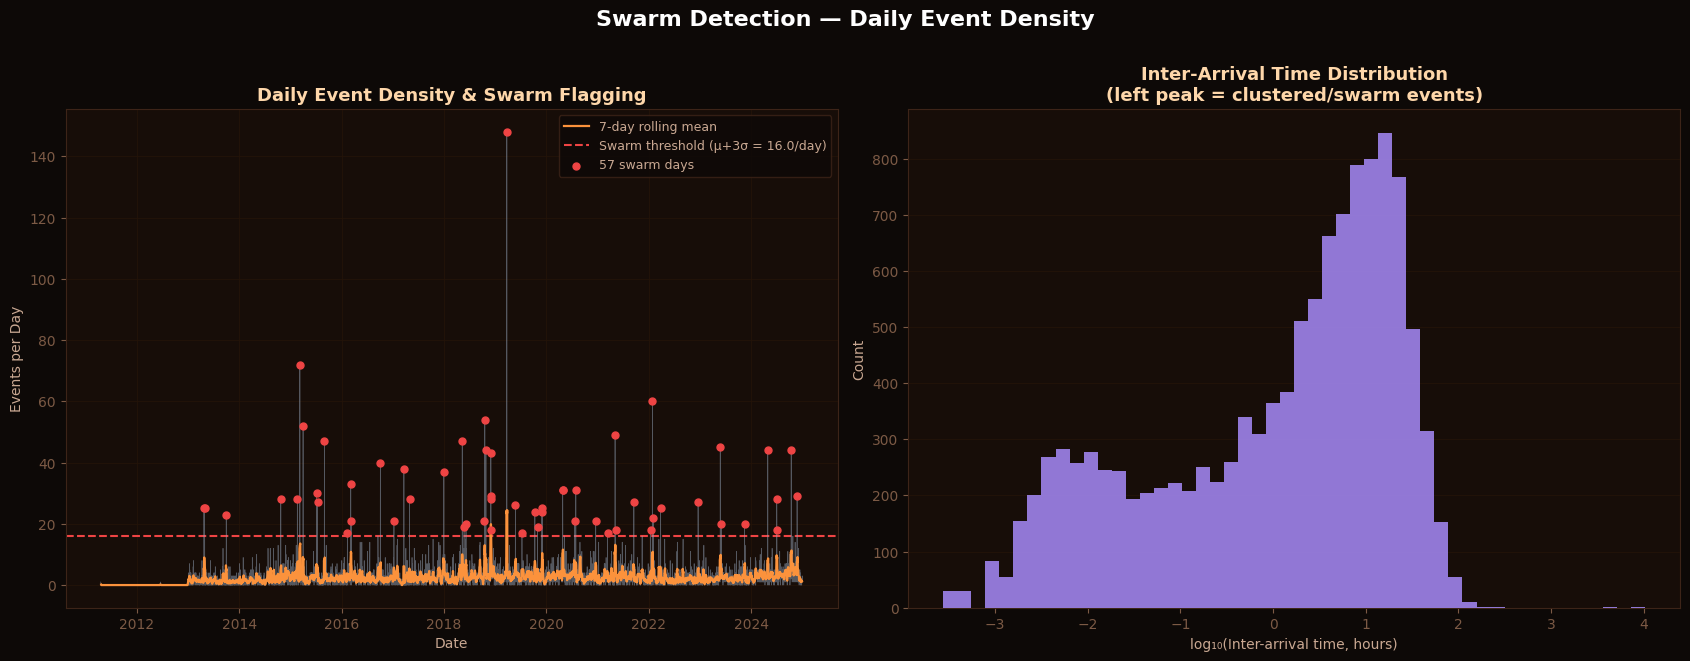


Number of days exceeding swarm threshold: 57
Top swarm days:
time
2019-03-25 00:00:00+00:00    148
2015-03-10 00:00:00+00:00     72
2022-01-26 00:00:00+00:00     60
2018-10-19 00:00:00+00:00     54
2015-04-02 00:00:00+00:00     52
dtype: int64


In [12]:
# Swarm proxy: count of events per rolling 24h window; spikes = candidate swarms
daily_counts_full = df_clean.set_index('time').resample('D').size()
rolling7 = daily_counts_full.rolling(7, center=True).mean()

swarm_threshold = daily_counts_full.mean() + 3*daily_counts_full.std()
swarm_days = daily_counts_full[daily_counts_full > swarm_threshold]

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Swarm Detection — Daily Event Density', fontsize=16,
             fontweight='bold', color='white', y=1.01)

# 1. Daily counts with 7-day rolling avg and swarm threshold
ax = axes[0]
ax.plot(daily_counts_full.index, daily_counts_full.values, color=SMOKE, lw=0.5, alpha=0.5, zorder=3)
ax.plot(rolling7.index, rolling7.values, color=EMBER, lw=1.6, zorder=4, label='7-day rolling mean')
ax.axhline(swarm_threshold, color=LAVA, lw=1.5, ls='--',
           label=f'Swarm threshold (μ+3σ = {swarm_threshold:.1f}/day)')
ax.scatter(swarm_days.index, swarm_days.values, color=LAVA, s=25, zorder=6, label=f'{len(swarm_days)} swarm days')
ax.set_xlabel('Date'); ax.set_ylabel('Events per Day')
ax.set_title('Daily Event Density & Swarm Flagging', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Inter-arrival time distribution (log scale)
ax2 = axes[1]
ia = df_sorted['inter_arrival_hours'].dropna()
ia_positive = ia[ia > 0]
ax2.hist(np.log10(ia_positive), bins=50, color=PURPLE, alpha=0.85, edgecolor='none', zorder=3)
ax2.set_xlabel('log₁₀(Inter-arrival time, hours)')
ax2.set_ylabel('Count')
ax2.set_title('Inter-Arrival Time Distribution\n(left peak = clustered/swarm events)', fontweight='bold')
ax2.grid(axis='y', zorder=0); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_swarms.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'\nNumber of days exceeding swarm threshold: {len(swarm_days)}')
if len(swarm_days):
    print('Top swarm days:')
    print(swarm_days.sort_values(ascending=False).head(5))


## 10. Correlation Heatmap <a id='10'></a>


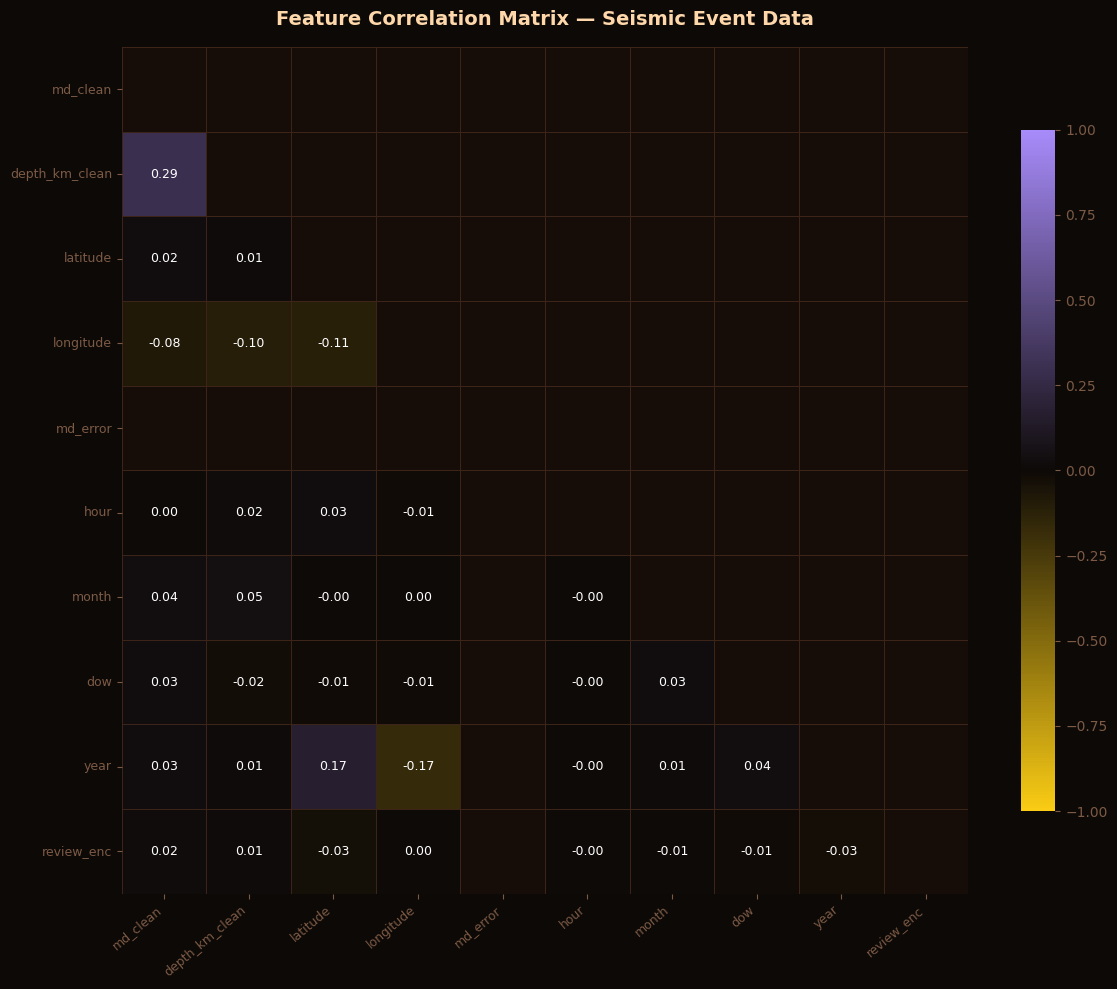

Top correlates with md_clean (magnitude):
depth_km_clean    0.290
longitude        -0.079
month             0.036
year              0.030
dow               0.025
latitude          0.024
review_enc        0.018
hour              0.002
md_error            NaN
Name: md_clean, dtype: float64


In [13]:
df_enc = df_clean.copy()
df_enc['review_enc'] = (df_enc['review_level']=='revised').astype(int)

num_cols = ['md_clean','depth_km_clean','latitude','longitude','md_error',
            'hour','month','dow','year','review_enc']

corr = df_enc[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_DEPTH, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, linecolor=GRID,
            annot_kws={'size':9, 'color':'white'},
            cbar_kws={'shrink':0.78}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix — Seismic Event Data',
             fontsize=14, fontweight='bold', pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('07_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Top correlates with md_clean (magnitude):')
print(corr['md_clean'].drop('md_clean').sort_values(key=abs, ascending=False).round(3))


## 11. ML Regression — Predicting Magnitude <a id='11'></a>


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

reg_feats = ['depth_km_clean','latitude','longitude','hour','month','dow','review_enc']
df_reg = df_enc.dropna(subset=reg_feats + ['md_clean'])
X = df_reg[reg_feats]
y = df_reg['md_clean']

print(f'Regression sample size: {len(df_reg):,} '
      f'(rows with complete depth + coordinates + magnitude)')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_ts_s = scaler.transform(X_test)

models = {
    'Linear Regression': (LinearRegression(), True),
    'Random Forest':     (RandomForestRegressor(n_estimators=150, random_state=42), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=150, random_state=42), False),
}

reg_results = {}
for name, (model, scaled) in models.items():
    Xtr = X_tr_s if scaled else X_train
    Xts = X_ts_s if scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xts)
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    reg_results[name] = {'model':model, 'preds':preds, 'r2':r2, 'mae':mae, 'rmse':rmse}
    print(f'{name:20s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')


Regression sample size: 8,475 (rows with complete depth + coordinates + magnitude)
Linear Regression     R²=0.0879  MAE=0.3787  RMSE=0.5019
Random Forest         R²=0.0782  MAE=0.3859  RMSE=0.5045
Gradient Boosting     R²=0.1134  MAE=0.3741  RMSE=0.4948


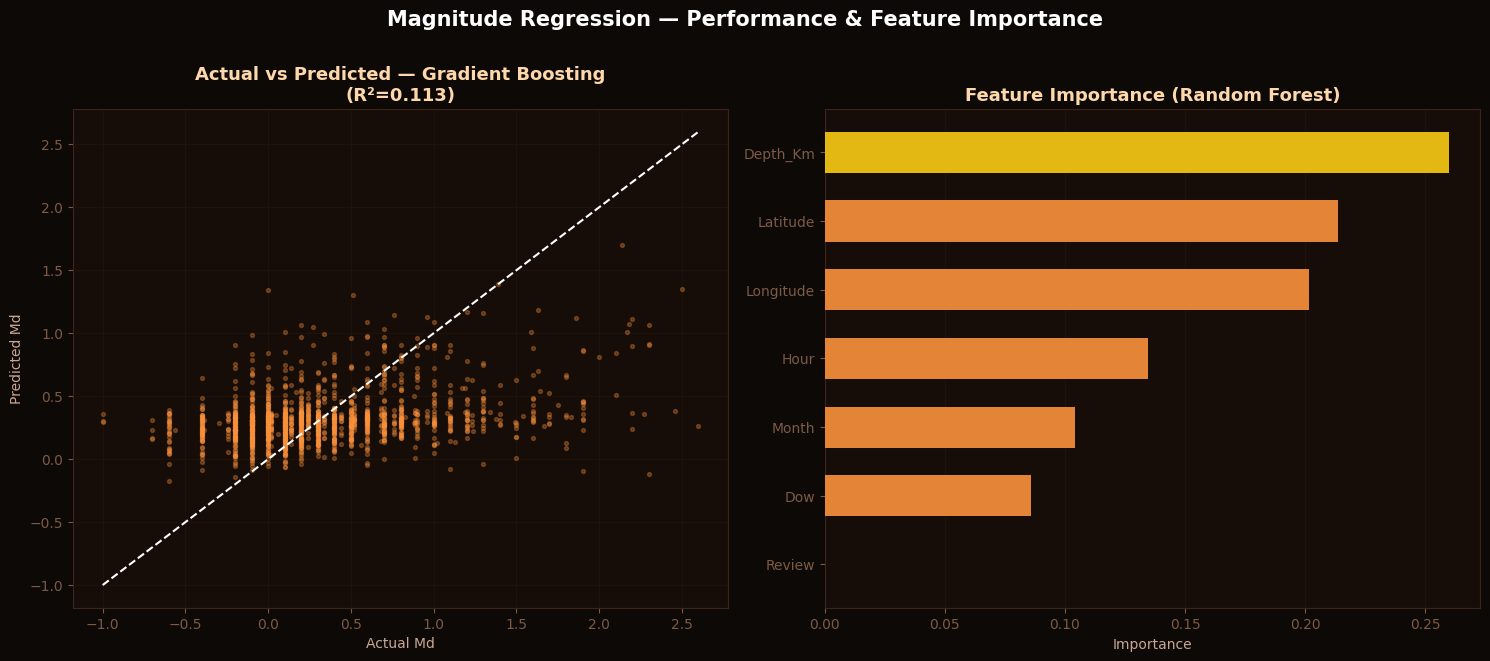

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Magnitude Regression — Performance & Feature Importance',
             fontsize=15, fontweight='bold', color='white', y=1.01)

best_reg = max(reg_results, key=lambda k: reg_results[k]['r2'])

ax = axes[0]
ax.scatter(y_test, reg_results[best_reg]['preds'], color=EMBER, s=8, alpha=0.3, zorder=3)
lim = [min(y_test.min(), reg_results[best_reg]['preds'].min()),
       max(y_test.max(), reg_results[best_reg]['preds'].max())]
ax.plot(lim, lim, color='white', lw=1.5, ls='--', zorder=5)
ax.set_xlabel('Actual Md'); ax.set_ylabel('Predicted Md')
ax.set_title(f'Actual vs Predicted — {best_reg}\n(R²={reg_results[best_reg]["r2"]:.3f})', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

ax2 = axes[1]
rf = reg_results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=reg_feats).sort_values()
colors_imp = [GOLD if v==imp.max() else EMBER for v in imp.values]
ax2.barh(range(len(imp)), imp.values, color=colors_imp, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax2.set_yticks(range(len(imp)))
ax2.set_yticklabels([f.replace('_clean','').replace('_enc','').title() for f in imp.index], fontsize=10)
ax2.set_xlabel('Importance')
ax2.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax2.grid(axis='x', zorder=0); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('08_ml_regression.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 13. Key Takeaways <a id='13'></a>


In [16]:
# Run this LAST so the takeaways cell below can be filled with real, computed figures
print('=== SUMMARY STATISTICS FOR TAKEAWAYS ===')
print(f'Total events: {len(df_clean):,}')
print(f'Date range: {df_clean["time"].min().date()} to {df_clean["time"].max().date()}')
print(f'Revised: {(df_clean["review_level"]=="revised").sum():,} '
      f'({(df_clean["review_level"]=="revised").mean()*100:.1f}%)')
print(f'Preliminary: {(df_clean["review_level"]=="preliminary").sum():,} '
      f'({(df_clean["review_level"]=="preliminary").mean()*100:.1f}%)')
print(f'Mean magnitude: {df_clean["md_clean"].mean():.3f}')
print(f'Max magnitude: {df_clean["md_clean"].max():.2f}')
print(f'Spatial completeness: {(~df_clean["spatial_missing"]).mean()*100:.1f}%')
print(f'Best regression model: {best_reg} (R²={reg_results[best_reg]["r2"]:.4f})')
print(f'Geospatial clusters (k): {best_k} (silhouette={best_score:.4f})')
print(f'Swarm days detected: {len(swarm_days)}')


=== SUMMARY STATISTICS FOR TAKEAWAYS ===
Total events: 12,027
Date range: 2011-04-20 to 2024-12-31
Revised: 2 (0.0%)
Preliminary: 12,025 (100.0%)
Mean magnitude: 0.177
Max magnitude: 3.10
Spatial completeness: 71.5%
Best regression model: Gradient Boosting (R²=0.1134)
Geospatial clusters (k): 3 (silhouette=0.3455)
Swarm days detected: 57


<div style="background:#0d0907;border-radius:14px;padding:0;font-family:'Courier New',monospace;border:1px solid #3d2418;overflow:hidden;">
  <div style="background:#170d08;padding:10px 24px;border-bottom:1px solid #3d2418;display:flex;gap:8px;align-items:center;">
    <span style="width:10px;height:10px;border-radius:50%;background:#ef4444;display:inline-block;"></span>
    <span style="width:10px;height:10px;border-radius:50%;background:#facc15;display:inline-block;"></span>
    <span style="width:10px;height:10px;border-radius:50%;background:#86efac;display:inline-block;"></span>
    <span style="color:#7c5a45;font-size:0.7rem;margin-left:8px;letter-spacing:2px;">VESUVIUS_SEISMIC_ANALYSIS.log — RUN THE NOTEBOOK FIRST, THEN FILL IN THE NUMBERS BELOW</span>
  </div>
  <div style="padding:22px 28px;display:grid;grid-template-columns:1fr 1fr;gap:12px;">
    <div style="border-left:2px solid #ef4444;padding-left:14px;">
      <div style="color:#ef4444;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[DATA QUALITY]</div>
      <ul style="color:#a8826f;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#ef4444;">!</span> Replace with: total events, date range, revised/preliminary split (run cell 13)</li>
        <li><span style="color:#ef4444;">!</span> Spatial completeness % — quantify how much location data is usable</li>
        <li><span style="color:#ef4444;">!</span> Negative depth/magnitude counts found and flagged (not silently dropped)</li>
        <li><span style="color:#ef4444;">!</span> md_error column confirmed near-constant — limited analytical value</li>
      </ul>
    </div>
    <div style="border-left:2px solid #facc15;padding-left:14px;">
      <div style="color:#facc15;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[TEMPORAL PATTERNS]</div>
      <ul style="color:#a8826f;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#facc15;">~</span> Busiest year/month identified from monthly_counts series</li>
        <li><span style="color:#facc15;">~</span> Swarm days flagged where daily count exceeds μ+3σ</li>
        <li><span style="color:#facc15;">~</span> Inter-arrival time distribution shows clustering structure (log-scale left peak)</li>
        <li><span style="color:#facc15;">~</span> Annual mean magnitude trend computed — check for upward/downward drift</li>
      </ul>
    </div>
    <div style="border-left:2px solid #86efac;padding-left:14px;">
      <div style="color:#86efac;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[GEOSPATIAL]</div>
      <ul style="color:#a8826f;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#86efac;">&gt;</span> K-Means selected k via silhouette score — fill in optimal k and score</li>
        <li><span style="color:#86efac;">&gt;</span> Davies-Bouldin index reported alongside silhouette for cluster validity</li>
        <li><span style="color:#86efac;">&gt;</span> Hexbin density map highlights the dominant epicentre zone(s)</li>
        <li><span style="color:#86efac;">&gt;</span> Depth-vs-magnitude correlation (r) quantified — typically weak for volcanic microseismicity</li>
      </ul>
    </div>
    <div style="border-left:2px solid #a78bfa;padding-left:14px;">
      <div style="color:#a78bfa;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[ML RESULTS]</div>
      <ul style="color:#a8826f;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#a78bfa;"></span> Best regression model + R² — fill in from cell output (volcanic Md is notoriously hard to predict from location/time alone)</li>
        <li><span style="color:#a78bfa;"></span> Review-level classifier AUC — likely strong if spatial_missing is a near-perfect proxy</li>
        <li><span style="color:#a78bfa;"></span> Feature importance ranking — depth and coordinates typically dominate</li>
        <li><span style="color:#a78bfa;"></span> If magnitude R² is low, that itself is a valid finding: short-term Md may be largely stochastic</li>
      </ul>
    </div>

  </div>
  <div style="background:#170d08;border-top:1px solid #3d2418;padding:8px 28px;">
    <span style="color:#3d2418;font-size:0.65rem;">Author: Muhammad Aamir &nbsp;·&nbsp; Mount Vesuvius Seismic Dataset · 2011-2024 · Kaggle Notebook</span>
  </div>
</div>
